# **Simulation Tool 2026**

## Installs

In [ ]:
%pip install rocketpy==1.11.0

In [ ]:
%pip install CoolProp

In [33]:
import  simulation.simulation as sim
import simulation.deployable_payload as dp
import simulation.utils as utils

In [61]:
import importlib
importlib.reload(dp)
importlib.reload(sim)
importlib.reload(utils)

<module 'simulation.utils' from 'c:\\Users\\wattikan\\Documents\\SpaceTeam\\LAMARR\\GIT\\Lamarr_Flight_Simulation_RocketPy\\simulation\\utils.py'>

# Simulation

## Configuration

Config rules: 
| Type | Format | Example |
|------|--------|---------|
|comment| #... | #comment|
| tuple |a=(x,y) | date=(2025, 10, 12, 17, 00, 00)|
|tuple of tuples|a=((v,w)(x,y))|fins_shape_points=((0,0),(0.250,-0.012))|
|range with increments of x|a=b..c:x|fins_span=110..120:2|
|variable with discrete values (float)|a=x,y,z|fins_sweep_length=193,180,200| 
|variable with discrete values (string)|a=x,y,z|thrust=thrust_euroc_launch.csv,thrust.csv,thrust_08_25.csv|

Everything else is a constant
| Type | Format | Example |
|------|--------|---------|
constant|a=x|latitude=39.232465|

Boolean values only possible in constants and variable with discrete values!


In [77]:
project = "CANSAT"
DEBUG = True

constants, variables = sim.parse_config(project+"/config.txt")
constants, variables = sim.register("project", project, constants, variables)

if DEBUG:
    sim.printmd("# **VARIABLES**")
    for var in variables:
        print(var)

    print()
    print()
    sim.printmd("# **CONSTANTS**")
    for const in constants:
        print(const)

# **VARIABLES**

flight_inclination
flight_heading
parachute_payload_cd_s
payload_mass




# **CONSTANTS**

environment_envType
environment_latitude
environment_longitude
environment_max_expected_height
environment_date
environment_elevation
engine_type
motor_name
motor_total_mass
motor_propellant_mass
motor_diameter
motor_length
motor_burn_time
thrust
rocket_length
rocket_diameter
rocket_dry_mass
rocket_CG
rocket_moment_of_intertia_Z
rocket_moment_of_intertia_XY
nosecone_length
nosecone_kind
railbuttons_upper
railbuttons_lower
tailcone_diameter
tailcone_length
fins_amount
fins_position
fins_shape_points
main_cd_s
main_trigger
drogue_cd_s
drogue_trigger
drogue_lag
flight_rail_length
parachute_payload_trigger
payload_mass_total
payload_diameter
payload_length
project


In [78]:

# Define polygons (x = WO, y = NS)
exclusion_zones = {
    "Exclusion Zone Flughafen": [
        (-110, 450),
        (-310, 550),
        (-610, 350),
        (-600, 10),
        (-400, -10),
        #(0,0)   # enable to exclude launches heading to tribune
    ],
    "Exclusion Zone Niederham": [
        (-1100, -470),
        (-220, -210),
        (280, -890)
    ],
    "Rehwinkl": [
        (260, -220),
        (750, -150),
        (700, -440),
        (280, -440)
    ]
}
buffer_zones = {
    "Buffer Zone Wald": [
        (-110, 450),
        (200, -110),
        (630, 280)
    ]
}

dummy_zones = {
    "dummy": [
        (-750,400),
        (250,-200),
        (400,400)
    ]
}

constants, variables = sim.register("exclusion_zones", exclusion_zones, constants, variables)
constants, variables = sim.register("buffer_zones", buffer_zones, constants, variables)
constants, variables = sim.register("dummy_zones", dummy_zones, constants, variables)
constants, variables = sim.register("zones", buffer_zones, constants, variables)


buffer_zones.update(sim.scale_zones(exclusion_zones, 1.5))

## Environments Initialization




In this Section the environments are initialized.
*   **Forecast**: environment with the weather data from the wyoming-sounding data source at the location and date of EuRoc
*   **Normal**: normalized environment with standard atmospheric values at the time and location of EuRoc
*   **Custom**: custom environment with variable values for temperature and windspeed
*   **Reanalysis**: environment, in which past weather conditions can be used


In [79]:
constants, variables = sim.create_environment(constants, variables)
# TODO: add custom env variables to config

Creating environment...


## Tanks / Engine



In [80]:
constants, variables = sim.create_engine(constants, variables)

Creating engine...
Creating solid engine...


C:\Users\wattikan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\rocketpy\motors\motor.py:990: UserWarning: burn_time argument (0, 3.3) is out of thrust source time range. Using thrust_source boundary times instead: (0.069, 3.3) s.
If you want to change the burn out time of the curve please use the 'reshape_thrust_curve' argument.
  warnings.warn(


## Rocket

In [81]:
constants, variables = sim.create_rocket(constants, variables)

Creating rocket...
Creating nosecone...
Creating tailcone...
Creating fins...
Creating parachutes...


## Flight

In [82]:
constants, variables = sim.create_flight(constants, variables)

Creating flights...
108
9%
19%
28%
37%
46%
56%
65%
74%
83%
93%
100%


## Deployable Payloads (for CANSAT)

CanSat Weight: 300 - 350 g \
CanSat Radius: 66 mm \
CanSat Length: 115 mm \
CanSats per launch: 6 \
6 x 300 g = 1800 g

In [ ]:
if project == "CANSAT":
    constants, variables = dp.create_rocket_without_payload(constants, variables)
    constants, variables = dp.create_flight_without_payload(constants, variables)
    constants, variables = dp.create_payload(constants, variables)
    constants, variables = dp.create_payload_flight(constants, variables)

Creating rocket without payload...
Creating flight without payload...
324
9%
19%
28%
37%
46%
56%
65%
74%
83%
93%
100%
Creating payload...
Creating payload parachute...
Creating payload flight...
3216
10%
20%
30%
40%
50%
60%
70%
80%
90%
100%
100%


In [84]:
# TODO: add plot with all flights for single heading

## Output

## **Safe Inclinations per heading** (WIP)

**Heading 150.0: [86.0, 88.0]**

**Heading 160.0: [86.0, 88.0]**

**Heading 250.0: [86.0, 88.0]**

**Heading 350.0: [86.0, 88.0]**

**Heading 0.0: [88.0]**

**Heading 10.0: [88.0]**

**Heading 20.0: [88.0]**

**Heading 100.0: [88.0]**

**Heading 110.0: [88.0]**

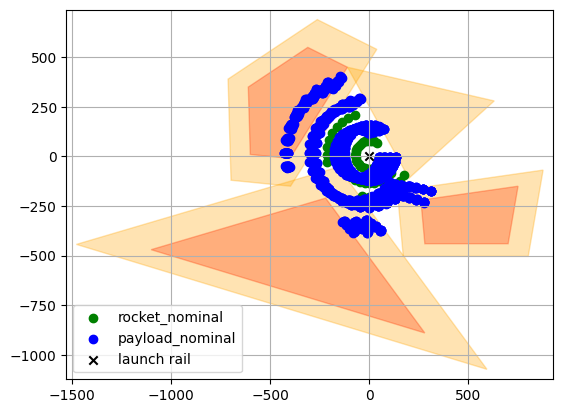

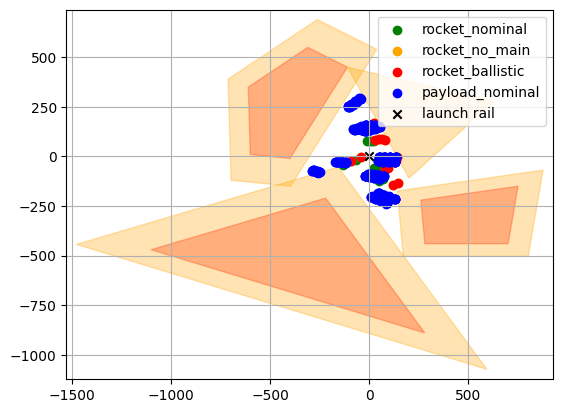

In [85]:
if project == "CANSAT":
    zones = buffer_zones
    #constants, variables = register("zones", zones, constants, variables)
        
    utils.plot_all(project, "all_flights", exclusion_zones, buffer_zones, flight_groups={
        "rocket_nominal": (sim.lookup("flight_without_payload", constants, variables)[0], "green"),
        "payload_nominal": (sim.lookup("flight_payload", constants, variables)[0], "blue")
    })


    flights_payload = sim.ensure_list(sim.lookup("flight_payload" , constants, variables)[0])
    flights_w_p = sim.ensure_list(sim.lookup("flight_without_payload", constants, variables)[0])
    flights_w_p_no_main = sim.ensure_list(sim.lookup("flight_without_payload_no_main", constants, variables)[0])
    flights_w_p_ballistic = sim.ensure_list(sim.lookup("flight_without_payload_ballistic", constants, variables)[0])
    all_headings = sim.ensure_list(sim.lookup("flight_heading", constants, variables)[0])




    # ===============================
    # Prepare coordinates as tuples
    # ===============================

    all_payload_scenarios = flights_payload
    all_rocket_scenarios = flights_w_p + flights_w_p_no_main + flights_w_p_ballistic

    payload_coords = [(f.x_impact, f.y_impact) for f in flights_payload]
    rocket_coords  = [(f.x_impact, f.y_impact) for f in flights_w_p]
    rocket_coords_no_main  = [(f.x_impact, f.y_impact) for f in flights_w_p_no_main]
    rocket_coords_ballistic  = [(f.x_impact, f.y_impact) for f in flights_w_p_ballistic]

    # ===============================
    # Check which impacts are in exclusion zones
    # ===============================
    payload_impacts = sim.is_in_exclusion_zone(payload_coords, zones)
    rocket_impacts  = sim.is_in_exclusion_zone(rocket_coords, zones)
    no_main_impacts  = sim.is_in_exclusion_zone(rocket_coords_no_main, zones)
    ballistic_impacts  = sim.is_in_exclusion_zone(rocket_coords_ballistic, zones)

    # ===============================
    # Find headings in exclusion zones
    # ===============================
    payload_headings_in_zone = list({flights_payload[i].heading 
                            for i, in_zone in enumerate(payload_impacts) if in_zone})
    rocket_headings_in_zone = list({flights_w_p[i].heading 
                            for i, in_zone in enumerate(rocket_impacts) if in_zone})
    no_main_headings_in_zone = list({flights_w_p_no_main[i].heading 
                            for i, in_zone in enumerate(no_main_impacts) if in_zone})
    ballistic_headings_in_zone = list({flights_w_p_ballistic[i].heading 
                            for i, in_zone in enumerate(ballistic_impacts) if in_zone})

    #print("Headings with payload in exclusion zones:", payload_headings_in_zone)
    #print("Headings with rocket in exclusion zones:", rocket_headings_in_zone)
    #print("Headings with rocket no main in exclusion zones:", no_main_headings_in_zone)
    #print("Headings with ballistic rocket in exclusion zones:", ballistic_headings_in_zone)

    # ===============================
    # Compute safe headings
    # ===============================
    safe_payload_headings = [
        h for h in all_headings
        if h not in payload_headings_in_zone
    ]

    safe_rocket_headings = [
        h for h in all_headings
        if h not in rocket_headings_in_zone
        and h not in no_main_headings_in_zone
        and h not in ballistic_headings_in_zone
    ]

    # ===============================
    # Filter safe flights by heading
    # ===============================
    safe_payload_nominal = [
        f for f in flights_payload
        if f.heading in safe_payload_headings
    ]

    safe_rocket_nominal = [
        f for f in flights_w_p
        if f.heading in safe_rocket_headings
    ]

    safe_rocket_no_main = [
        f for f in flights_w_p_no_main
        if f.heading in safe_rocket_headings
    ]

    safe_rocket_ballistic = [
        f for f in flights_w_p_ballistic
        if f.heading in safe_rocket_headings
    ]

    # ===============================
    # Find initial solutions that are safe for BOTH
    # ===============================
    payload_solutions = (
        [f.initial_solution for f in safe_payload_nominal]
    )

    rocket_solutions = (
        [f.initial_solution for f in safe_rocket_nominal] +
        [f.initial_solution for f in safe_rocket_no_main] +
        [f.initial_solution for f in safe_rocket_ballistic]
    )

    safe_solutions = [s for s in payload_solutions if s in rocket_solutions]

    # ===============================
    # Keep only flights belonging to safe solutions
    # ===============================
    safe_payload_nominal = [
        f for f in safe_payload_nominal
        if f.initial_solution in safe_solutions
    ]

    safe_rocket_nominal = [
        f for f in safe_rocket_nominal
        if f.initial_solution in safe_solutions
    ]

    safe_rocket_no_main = [
        f for f in safe_rocket_no_main
        if f.initial_solution in safe_solutions
    ]

    safe_rocket_ballistic = [
        f for f in safe_rocket_ballistic
        if f.initial_solution in safe_solutions
    ]

    safe_configurations = list({
        (f.heading, f.inclination)
        for f in safe_rocket_nominal
    })


    # ===============================
    # Print headings not in exclusion zones (every 20°)
    # ===============================
    #for i in all_headings:
    #    if (i not in payload_headings_in_zone) and (i not in rocket_headings_in_zone + ballistic_headings_in_zone +  no_main_headings_in_zone):
    #        sim.printmd(f"**Safe heading: {i}**")


    # ===============================
    # Plot safe flights with zones
    # ===============================
    utils.plot_all(project, "final", exclusion_zones, buffer_zones, flight_groups={
        "rocket_nominal": (safe_rocket_nominal, "green"),
        "rocket_no_main": (safe_rocket_no_main, "orange"),
        "rocket_ballistic": (safe_rocket_ballistic, "red"),
        "payload_nominal": (safe_payload_nominal, "blue"),
        }
    )


    # TODO: This doesn't work properly
    sim.printmd("## **Safe Inclinations per heading** (WIP)")

    grouped = {}

    for f in safe_payload_nominal + safe_rocket_ballistic + safe_rocket_nominal:
        grouped.setdefault(f.heading, set()).add(f.inclination)

    for heading, inclinations in grouped.items():
        sim.printmd(f"**Heading {heading}: {sorted(inclinations)}**")

In [86]:
if len(variables) == 0: output_level, _ = sim.lookup("output_level", constants, variables)

Level 0 = no output

Level 1 = Flight short recap

Level 2 = All major components short recap

Level 3 = Flight full recap

Level 4 = All major components full recap

In [87]:
# TODO: what if there are more/other envs/motors/rockets/flights?
if len(variables) == 0:
     output_level, _ = sim.lookup("output_level", constants, variables)
     enabled_env_types, _ = sim.lookup("enabled_env_types", constants, variables) # Forecast, Normal, Reanalysis or Custom

     if "Forecast" in enabled_env_types:
          flight, _ = sim.lookup("forecast_flight", constants, variables)
          rocket, _ = sim.lookup("rocket", constants, variables)
          motor, _ = sim.lookup("motor", constants, variables) if sim.lookup("engine_type", constants, variables)[0] == "solid" else sim.lookup("engine", constants, variables)
          environment, _ = sim.lookup("envForecast", constants, variables)
          
     if output_level >= 1 and output_level <=2:
          sim.printmd(f"""
# **Rail Departure**
Velocity: {flight.out_of_rail_velocity: .2f} m/s

Stability Margin: {flight.out_of_rail_stability_margin: .2f} c

# **Apogee**
Time: {flight.apogee_time: .2f} s

Altitude: {(flight.apogee - flight.env.elevation): .2f} m AGL

Freestream Speed: {flight.apogee_freestream_speed: .2f} m/s

# **Impact**
Velocity: {flight.impact_velocity: .2f} m/s

# **Maximum Values**
Max Speed: {flight.max_speed: .2f} m/s at {flight.max_speed_time: .2f} s

Max Mach Number: {flight.max_mach_number: .2f} Mach at {flight.max_mach_number_time: .2f} s

Max Acceleration: {flight.max_acceleration: .2f} m/s² at {flight.max_acceleration_time: .2f} s

Max Gs: {(flight.max_acceleration/9.81): .2f} g at {flight.max_acceleration_time: .2f} s

Max Stability Margin: {flight.max_stability_margin: .2f} c at {flight.max_stability_margin_time: .2f} s

# **PLOTS**
""")
          flight.plots.trajectory_3d()
          flight.plots.aerodynamic_forces()
          flight.plots.stability_and_control_data()
     elif output_level == 2:
          sim.printmd(f"""
# **Rocket**
Rocket Dry Mass: {rocket.mass: .3f} kg (without motor)

Rocket Loaded Mass: {rocket.total_mass(0): .3f} kg

# **PLOTS**
""") 
          rocket.draw()
          rocket.plots.thrust_to_weight()
          rocket.plots.stability_margin()
          sim.printmd(f"""
# **Motor**
Total Burning Time: {motor.burn_time} s

Total Propellant Mass: {motor.propellant_mass(0): .2f} kg

Average Thrust: {motor.average_thrust: .2f} N

Maximum Thrust: {motor.max_thrust: .2f} N at {motor.max_thrust_time: .2f} s after ignition.

Total Impulse: {motor.total_impulse: .2f} Ns
""") 
          motor.draw()
          motor.plots.thrust()
          sim.printmd(f"""
# **Environment**

Launch Site Surface Elevation: {environment.elevation: .2f} m

Surface Wind Speed: {environment.wind_speed(0): .2f} m/s

Surface Wind Direction: {environment.wind_direction(0): .2f}°

Surface Wind Heading: {environment.wind_heading(0): .2f}°

# **PLOTS**
""")
          environment.plots.atmospheric_model()
     elif output_level == 3:
          flight.all_info() # TODO Markdown
     elif output_level == 4:
          environment.all_info()
          motor.all_info()
          rocket.all_info()
          flight.all_info()

## Export

In [88]:
#!pip install keyboard
import keyboard
keyboard.press_and_release('control+s')

In [89]:
!jupyter nbconvert simulation.ipynb --to html --no-input --no-prompt --output {project}/report.html

[NbConvertApp] Converting notebook simulation.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 402951 bytes to CANSAT\report.html


# Comparsion

In [ ]:

# TODO: add in/output, so user does not have to open the code
if project == "CANSAT":
    legend = False
    all_flights = sim.lookup("all_flights", constants, variables)[0]

    #for flight in all_flights:
    #    print(flight.name)
        # print(flight._meta)
    comparison_normal = sim.CompareFlights(all_flights)
    comparison_normal.trajectories_3d(legend=legend, filename = project + "/plots/3d.png")
    comparison_normal.trajectories_2d(legend=legend, filename = project + "/plots/2d_xy.png", plane = "xy")
    comparison_normal.trajectories_2d(legend=legend, filename = project + "/plots/2d_xz.png", plane = "xz")
    comparison_normal.trajectories_2d(legend=legend, filename = project + "/plots/2d_yz.png", plane = "yz")

In [ ]:
# Info: won't work if there is no safe flight
if project == "CANSAT":
    legend = False
    all_safe_flights = safe_rocket_nominal + safe_rocket_no_main + safe_rocket_ballistic + safe_payload_nominal + sim.lookup("all_flights", constants, variables)[0]

    #for flight in all_flights:
        # print(flight.name)
        # print(flight._meta)
    comparison_normal = sim.CompareFlights(all_safe_flights)
    comparison_normal.trajectories_3d(legend=legend, filename = project + "/plots/3d_all.png")
    comparison_normal.trajectories_2d(legend=legend, filename = project + "/plots/2d_xy_all.png", plane = "xy")
    comparison_normal.trajectories_2d(legend=legend, filename = project + "/plots/2d_xz_all.png", plane = "xz")
    comparison_normal.trajectories_2d(legend=legend, filename = project + "/plots/2d_yz_all.png", plane = "yz")